For binary synchronization,

$$Y_{uv}=\sigma_u\sigma_v Z_{uv},\qquad \mathbb E Z_{uv}=q_{uv},$$

this notebook estimates the normalized squared correlation achieved by loopy BP and compares it with the information-percolation upper bound

$$\frac{\mathbb E[f(Y)\sigma_s\sigma_t]^2}{\mathbb E[f(Y)^2]}\leq \operatorname{Corr}^2(s,t)\leq \mathbb P_{q^2}(s\leftrightarrow t).$$

The notebook uses NumPy and Matplotlib for Monte Carlo bookkeeping and visualization.

In [1]:
from dataclasses import dataclass
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:

@dataclass(frozen=True)
class Edge:
    u: object
    v: object
    q: float


class Graph:
    """Undirected multigraph with one BSC reliability q per edge."""

    def __init__(self):
        self.nodes = []
        self._node_set = set()
        self.edges = []

    def add_edge(self, u, v, q):
        if u == v:
            raise ValueError("Self-loops are not supported.")
        if not 0 <= q < 1:
            raise ValueError("q must lie in [0, 1).")
        for node in (u, v):
            if node not in self._node_set:
                self._node_set.add(node)
                self.nodes.append(node)
        self.edges.append(Edge(u, v, float(q)))
        return len(self.edges) - 1

    def adjacency(self):
        adj = {u: [] for u in self.nodes}
        for edge_id, edge in enumerate(self.edges):
            adj[edge.u].append((edge.v, edge_id))
            adj[edge.v].append((edge.u, edge_id))
        return adj


## Loopy belief propagation

We clamp $\sigma_s=+1$ and propagate cavity magnetizations. On a tree this is exact; on a graph with cycles it is ordinary loopy BP.

In [3]:
@dataclass(frozen=True)
class BPResult:
    correlation: float
    converged: bool
    iterations: int
    residual: float


def _clip(x, eps=1e-15):
    return max(-1 + eps, min(1 - eps, x))


def loopy_bp(graph, y, source, target, *, max_iter=500, damping=0.5, tol=1e-10):
    """Approximate E[sigma_source sigma_target | Y=y]."""
    if len(y) != len(graph.edges):
        raise ValueError("Supply one +/-1 observation per edge.")
    if not 0 < damping <= 1:
        raise ValueError("damping must lie in (0, 1].")

    adj = graph.adjacency()
    messages = {}
    for edge_id, edge in enumerate(graph.edges):
        messages[edge.u, edge_id] = 1.0 if edge.u == source else 0.0
        messages[edge.v, edge_id] = 1.0 if edge.v == source else 0.0

    residual = math.inf
    for iteration in range(1, max_iter + 1):
        updated = {}
        residual = 0.0
        for u in graph.nodes:
            for _, excluded_edge in adj[u]:
                key = (u, excluded_edge)
                if u == source:
                    new = 1.0
                else:
                    field = 0.0
                    for w, edge_id in adj[u]:
                        if edge_id == excluded_edge:
                            continue
                        theta = graph.edges[edge_id].q * y[edge_id]
                        field += math.atanh(_clip(theta * messages[w, edge_id]))
                    raw = math.tanh(field)
                    new = (1 - damping) * messages[key] + damping * raw
                updated[key] = new
                residual = max(residual, abs(new - messages[key]))
        messages = updated
        if residual < tol:
            break

    field = 0.0
    for u, edge_id in adj[target]:
        theta = graph.edges[edge_id].q * y[edge_id]
        field += math.atanh(_clip(theta * messages[u, edge_id]))
    return BPResult(math.tanh(field), residual < tol, iteration, residual)


## Estimate BP squared correlation

Each Monte Carlo sample draws a full planted spin vector $\sigma\in\{\pm1\}^n$, then draws edge noise and forms $Y_{uv}=\sigma_u\sigma_v Z_{uv}$. For a BP output $f(Y)$, we estimate

$$\frac{\mathbb E[f(Y)\sigma_s\sigma_t]^2}{\mathbb E[f(Y)^2]}.$$

In [4]:
@dataclass(frozen=True)
class BPPerformance:
    corr2: float
    numerator_mean: float
    denominator_mean: float
    standard_error: float
    convergence_rate: float


def edge_reliabilities(graph):
    return np.asarray([edge.q for edge in graph.edges], dtype=float)


def sample_spin_observations(graph, rng):
    node_index = {node: i for i, node in enumerate(graph.nodes)}
    sigma = rng.choice(np.array([-1, 1]), size=len(graph.nodes))
    q = edge_reliabilities(graph)
    noise = np.where(rng.random(len(q)) < (1 + q) / 2, 1, -1)
    observations = np.empty(len(graph.edges), dtype=int)
    for edge_id, edge in enumerate(graph.edges):
        observations[edge_id] = (
            sigma[node_index[edge.u]] * sigma[node_index[edge.v]] * noise[edge_id]
        )
    return sigma, observations, node_index


def estimate_bp_performance(graph, source, target, *, samples=5_000, seed=0):
    if samples <= 0:
        raise ValueError("samples must be positive.")

    rng = np.random.default_rng(seed)
    numerator_terms = np.empty(samples)
    denominator_terms = np.empty(samples)
    converged = 0
    for sample_id in range(samples):
        sigma, observations, node_index = sample_spin_observations(graph, rng)
        result = loopy_bp(graph, observations, source, target)
        true_pair = sigma[node_index[source]] * sigma[node_index[target]]
        numerator_terms[sample_id] = result.correlation * true_pair
        denominator_terms[sample_id] = result.correlation**2
        converged += result.converged

    numerator_mean = float(numerator_terms.mean())
    denominator_mean = float(denominator_terms.mean())
    corr2 = numerator_mean * numerator_mean / denominator_mean if denominator_mean else 0.0

    if samples > 1 and denominator_mean:
        numerator_variance = float(np.var(numerator_terms, ddof=1))
        denominator_variance = float(np.var(denominator_terms, ddof=1))
        covariance = float(np.cov(numerator_terms, denominator_terms, ddof=1)[0, 1])
        grad_numerator = 2 * numerator_mean / denominator_mean
        grad_denominator = -(numerator_mean / denominator_mean)**2
        variance = (
            grad_numerator**2 * numerator_variance
            + grad_denominator**2 * denominator_variance
            + 2 * grad_numerator * grad_denominator * covariance
        ) / samples
        standard_error = math.sqrt(max(0.0, variance))
    else:
        standard_error = 0.0

    return BPPerformance(
        corr2=corr2,
        numerator_mean=numerator_mean,
        denominator_mean=denominator_mean,
        standard_error=standard_error,
        convergence_rate=converged / samples,
    )


def exact_bp_performance(graph, source, target, *, max_observation_bits=24):
    """Exactly compute the normalized BP correlation for small graphs."""
    m = len(graph.edges)
    if m > max_observation_bits:
        raise ValueError("Exact BP enumeration is exponential in the number of edges.")

    node_index = {node: i for i, node in enumerate(graph.nodes)}
    n = len(graph.nodes)
    spins = np.array(
        [[1 if (bits >> i) & 1 else -1 for i in range(n)] for bits in range(1 << n)]
    )
    first = 0.0
    second = 0.0
    converged = 0.0
    prior = 1.0 / (1 << n)

    for y_bits in range(1 << m):
        observations = np.array(
            [1 if (y_bits >> edge_id) & 1 else -1 for edge_id in range(m)]
        )
        probability_y = 0.0
        weighted_pair = 0.0

        for sigma in spins:
            probability = prior
            for edge_id, edge in enumerate(graph.edges):
                z = observations[edge_id] * sigma[node_index[edge.u]] * sigma[node_index[edge.v]]
                probability *= (1 + edge.q * z) / 2
            true_pair = sigma[node_index[source]] * sigma[node_index[target]]
            probability_y += probability
            weighted_pair += probability * true_pair

        result = loopy_bp(graph, observations, source, target)
        first += result.correlation * weighted_pair
        second += result.correlation**2 * probability_y
        converged += probability_y * result.converged

    corr2 = first * first / second if second else 0.0
    return BPPerformance(corr2, first, second, 0.0, converged)


## Information-percolation upper bound

Open edge $e$ independently with probability $q_e^2$ and test whether $s$ and $t$ are connected. For the small graphs below we compute this probability exactly; Monte Carlo can report zero when the true connection probability is positive but very small.

In [5]:
@dataclass(frozen=True)
class PercolationEstimate:
    mean: float
    standard_error: float


def connected(graph, opened, source, target):
    adj = graph.adjacency()
    seen = {source}
    stack = [source]
    while stack:
        u = stack.pop()
        if u == target:
            return True
        for v, edge_id in adj[u]:
            if opened[edge_id] and v not in seen:
                seen.add(v)
                stack.append(v)
    return False


def percolation_bound_exact(graph, source, target):
    """Exact P(source connected to target) for small graphs."""
    m = len(graph.edges)
    if m > 24:
        raise ValueError("Exact percolation is exponential; use Monte Carlo for m > 24.")

    q = edge_reliabilities(graph)
    open_probability = np.clip(q * q, 0.0, 1.0)
    total = 0.0
    for bits in range(1 << m):
        opened = np.array([(bits >> edge_id) & 1 for edge_id in range(m)], dtype=bool)
        probability = float(np.prod(np.where(opened, open_probability, 1 - open_probability)))
        if connected(graph, opened, source, target):
            total += probability
    return PercolationEstimate(min(1.0, max(0.0, total)), 0.0)


def estimate_percolation_bound(graph, source, target, *, samples=20_000, seed=1):
    if samples <= 0:
        raise ValueError("samples must be positive.")

    rng = np.random.default_rng(seed)
    q = edge_reliabilities(graph)
    open_probability = np.clip(q * q, 0.0, 1.0)
    opened_samples = rng.random((samples, len(q))) < open_probability
    successes = 0
    for opened in opened_samples:
        successes += connected(graph, opened, source, target)
    mean = successes / samples
    mean = min(1.0, max(0.0, mean))
    return PercolationEstimate(mean, math.sqrt(mean * (1 - mean) / samples))


## Exact small-graph comparison

For these small graphs we enumerate all observations to compute the BP correlation exactly, and enumerate all open-edge sets to compute the percolation probability exactly. This is the table to use when checking that the percolation probability is an upper bound.

In [6]:
def path_graph(qs):
    graph = Graph()
    for i, q in enumerate(qs):
        graph.add_edge(i, i + 1, q)
    return graph, 0, len(qs)


def cycle_graph(qs):
    graph = Graph()
    for i, q in enumerate(qs):
        graph.add_edge(i, (i + 1) % len(qs), q)
    return graph, 0, len(qs) // 2


def heterogeneous_graph():
    graph = Graph()
    for u, v, q in [
        ("s", "a", 0.2), ("a", "b", 0.2), ("b", "s", 0.2),
        ("b", "c", 0.2), ("a", "c", 0.2), ("c", "d", 0.2),
        ("c", "e", 0.2), ("d", "e", 0.2), ("d", "t", 0.2),
        ("e", "t", 0.2),
    ]:
        graph.add_edge(u, v, q)
    return graph, "s", "t"


cases = [
    ("heterogeneous path", *path_graph([0.2, 0.2, 0.2])),
    ("heterogeneous cycle", *cycle_graph([0.2, 0.2, 0.2, 0.2])),
    ("heterogeneous graph", *heterogeneous_graph()),
]

print(
    f"{'case':24s} {'BP exact':>12s} {'E[fX]':>12s} "
    f"{'E[f^2]':>12s} {'perc. exact':>12s} {'gap':>12s} {'bound ok':>9s} {'BP conv.':>10s}"
)
for name, graph, source, target in cases:
    bp = exact_bp_performance(graph, source, target)
    upper = percolation_bound_exact(graph, source, target)
    gap = upper.mean - bp.corr2
    if abs(gap) < 1e-12:
        gap = 0.0
    bound_ok = bp.corr2 <= upper.mean + 1e-12
    print(
        f"{name:24s} {bp.corr2:12.6e} {bp.numerator_mean:12.6e} "
        f"{bp.denominator_mean:12.6e} {upper.mean:12.6e} "
        f"{gap:12.6e} {str(bound_ok):>9s} {bp.convergence_rate:10.3f}"
    )


case                         BP exact        E[fX]       E[f^2]  perc. exact          gap  bound ok   BP conv.
heterogeneous path       6.400000e-05 6.400000e-05 6.400000e-05 6.400000e-05 0.000000e+00      True      1.000
heterogeneous cycle      3.194888e-03 3.194888e-03 3.194888e-03 3.197440e-03 2.551821e-06      True      1.000
heterogeneous graph      1.089876e-05 1.114254e-05 1.139177e-05 1.099191e-05 9.315194e-08      True      1.000


## Monte Carlo convergence

This table shows the normalized Monte Carlo estimator $\mathbb E[f(Y)\sigma_s\sigma_t]^2 / \mathbb E[f(Y)^2]$ as the number of samples increases. Finite-sample estimates can overshoot the exact percolation upper bound when the true correlation is very small, so use the exact table above for the inequality check.

In [7]:
graph, source, target = heterogeneous_graph()
sample_sizes = [200, 1_000, 5_000, 20_000]

print(f"{'samples':>8s} {'corr^2':>10s} {'s.e.':>10s} {'E[fX]':>10s} {'E[f^2]':>10s} {'conv.':>8s}")
for samples in sample_sizes:
    estimate = estimate_bp_performance(graph, source, target, samples=samples, seed=11)
    print(
        f"{samples:8d} {estimate.corr2:10.5f} {estimate.standard_error:10.5f} "
        f"{estimate.numerator_mean:10.5f} {estimate.denominator_mean:10.5f} "
        f"{estimate.convergence_rate:8.3f}"
    )

 samples     corr^2       s.e.      E[fX]     E[f^2]    conv.
     200    0.00813    0.01266    0.00032    0.00001    1.000
    1000    0.00244    0.00310    0.00016    0.00001    1.000
    5000    0.00070    0.00075    0.00009    0.00001    1.000
   20000    0.00009    0.00013    0.00003    0.00001    1.000


## Graph visualization

Edges are colored by reliability $q_e$, and the source/target vertices are highlighted.

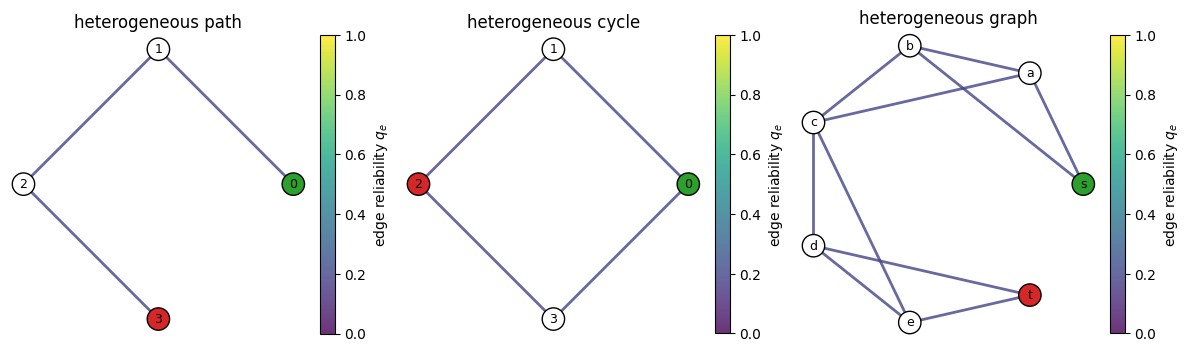

In [8]:
def circular_layout(nodes):
    angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
    coordinates = np.column_stack([np.cos(angles), np.sin(angles)])
    return {node: coordinates[i] for i, node in enumerate(nodes)}


def plot_graph(graph, source=None, target=None, *, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    pos = circular_layout(graph.nodes)
    if graph.edges:
        segments = np.asarray([[pos[edge.u], pos[edge.v]] for edge in graph.edges])
        q = edge_reliabilities(graph)
        lines = LineCollection(segments, cmap="viridis", linewidths=2.0, alpha=0.8)
        lines.set_array(q)
        lines.set_clim(0.0, 1.0)
        ax.add_collection(lines)
        plt.colorbar(lines, ax=ax, fraction=0.046, pad=0.04, label=r"edge reliability $q_e$")

    xy = np.asarray([pos[node] for node in graph.nodes])
    colors = [
        "tab:green" if node == source else "tab:red" if node == target else "white"
        for node in graph.nodes
    ]
    ax.scatter(xy[:, 0], xy[:, 1], s=260, c=colors, edgecolors="black", zorder=3)
    for node, (x, y) in pos.items():
        ax.text(x, y, str(node), ha="center", va="center", fontsize=9, zorder=4)

    ax.set_aspect("equal")
    ax.axis("off")
    return ax


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, graph, source, target) in zip(axes, cases):
    plot_graph(graph, source, target, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()